# Praktikum 2 — Preprocessing Data House Prices

Dataset: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data) (`train.csv`)

Alur pengerjaan:
1. Unduh dan import dataset
2. Pembersihan data (missing value)
3. Deteksi dan penanganan outlier
4. Transformasi data (standarisasi + one-hot encoding)
5. Reduksi dimensi (korelasi + PCA)

In [1]:
# import semua yang dibutuhkan
import kagglehub
from dotenv import load_dotenv
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

load_dotenv()
sns.set_theme(style="whitegrid")

## 1. Unduh dan Import Dataset

In [2]:
# download competition files (butuh KAGGLE credentials di .env)
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
print("Path to competition files:", path)
print("Isi folder:", os.listdir(path))

df = pd.read_csv(os.path.join(path, 'train.csv'))

Path to competition files: /home/irzam/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques
Isi folder: ['data_description.txt', 'sample_submission.csv', 'test.csv', 'train.csv']


In [3]:
display(df.head())
print("Shape:", df.shape)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Shape: (1460, 81)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

- **Q (Question)**: seperti apa struktur datanya?
- **S (Saw)**: 1460 baris × 81 kolom; 43 kolom teks (`str`), 35 `int64`, 3 `float64`
- **M (Means)**:
    - `Id` hanya penanda baris, tidak punya makna untuk analisis
    - `SalePrice` adalah target (harga rumah), sisanya 79 fitur
    - beberapa kolom di `.info()` non-null count-nya jauh di bawah 1460 → ada missing value
- **D (Do)**: cek missing value per kolom

## 2. Pembersihan Data

In [5]:
# jumlah & persentase nilai hilang per atribut (hanya yang ada missing-nya)
missing = pd.DataFrame({
    'jumlah': df.isna().sum(),
    'persen': df.isna().mean() * 100,
})
missing = missing[missing['jumlah'] > 0].sort_values('persen', ascending=False)
display(missing)
print("Jumlah kolom yang punya missing value:", len(missing))

,jumlah,persen
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


Jumlah kolom yang punya missing value: 19


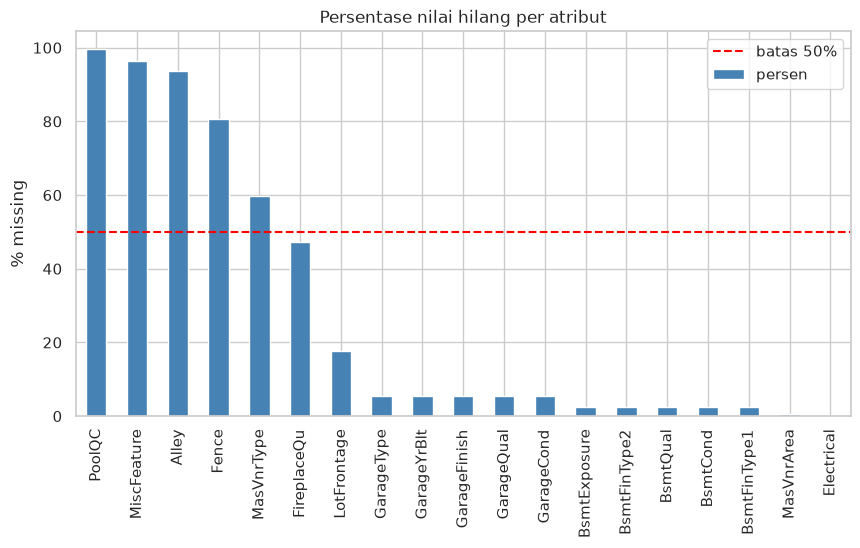

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
missing['persen'].plot.bar(ax=ax, color='steelblue')
ax.axhline(50, color='red', linestyle='--', label='batas 50%')
ax.set_ylabel('% missing')
ax.set_title('Persentase nilai hilang per atribut')
ax.legend()
plt.show()

In [7]:
# hapus kolom dengan missing > 50%, sekalian buang Id (cuma identifier)
cols_drop = missing[missing['persen'] > 50].index.tolist()
print("Kolom yang dihapus (>50% missing):", cols_drop)

df_clean = df.drop(columns=cols_drop + ['Id'])
print("Shape setelah drop:", df_clean.shape)

Kolom yang dihapus (>50% missing): ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']
Shape setelah drop: (1460, 75)


- **Q**: kenapa kolom-kolom ini banyak yang kosong?
- **S**: `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType` kosong >50%
- **M**: menurut `data_description.txt`, NaN di kolom-kolom ini sebenarnya artinya **"tidak punya"** (tidak ada kolam, tidak ada pagar, dst.). Tapi karena mayoritas isinya kosong, informasinya sangat sedikit → sesuai instruksi, dihapus.
- **D**: tangani sisa missing value dengan strategi yang sesuai arti kolomnya

**Strategi penanganan sisa missing value:**

| Kolom | Arti NaN | Penanganan |
|---|---|---|
| `FireplaceQu`, `Garage*` (kategori), `Bsmt*` (kategori) | rumah tidak punya perapian/garasi/basement | isi `"None"` (jadi kategori sendiri) |
| `GarageYrBlt` | tidak punya garasi | isi dengan `YearBuilt` (mengisi 0 akan bikin outlier ekstrem) |
| `MasVnrArea` | tidak ada veneer | isi `0` |
| `LotFrontage` | data memang tidak tercatat | median per `Neighborhood` (rumah di lingkungan yang sama cenderung punya lebar muka lahan mirip) |
| `Electrical` | cuma 1 baris kosong | isi modus |

In [8]:
none_cols = ['FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
df_clean[none_cols] = df_clean[none_cols].fillna('None')

df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(df_clean['YearBuilt'])
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)

df_clean['LotFrontage'] = (
    df_clean.groupby('Neighborhood')['LotFrontage']
    .transform(lambda s: s.fillna(s.median()))
    .fillna(df_clean['LotFrontage'].median())   # jaga-jaga kalau ada neighborhood yang kosong semua
)

df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

print("Total missing value tersisa:", df_clean.isna().sum().sum())

Total missing value tersisa: 0


## 3. Deteksi dan Penanganan Outlier

Catatan: `MSSubClass` isinya angka (20, 60, 120, ...) tapi sebenarnya **kode tipe rumah**, bukan besaran. Jadi diubah ke kategori dulu supaya tidak ikut dianggap numerik (tidak diboxplot/standarisasi, nanti di-one-hot).

In [9]:
df_clean['MSSubClass'] = df_clean['MSSubClass'].astype(str)

# atribut numerik (SalePrice = target, dipisah)
num_cols = df_clean.select_dtypes('number').columns.drop('SalePrice').tolist()
print(len(num_cols), "atribut numerik:", num_cols)

35 atribut numerik: ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


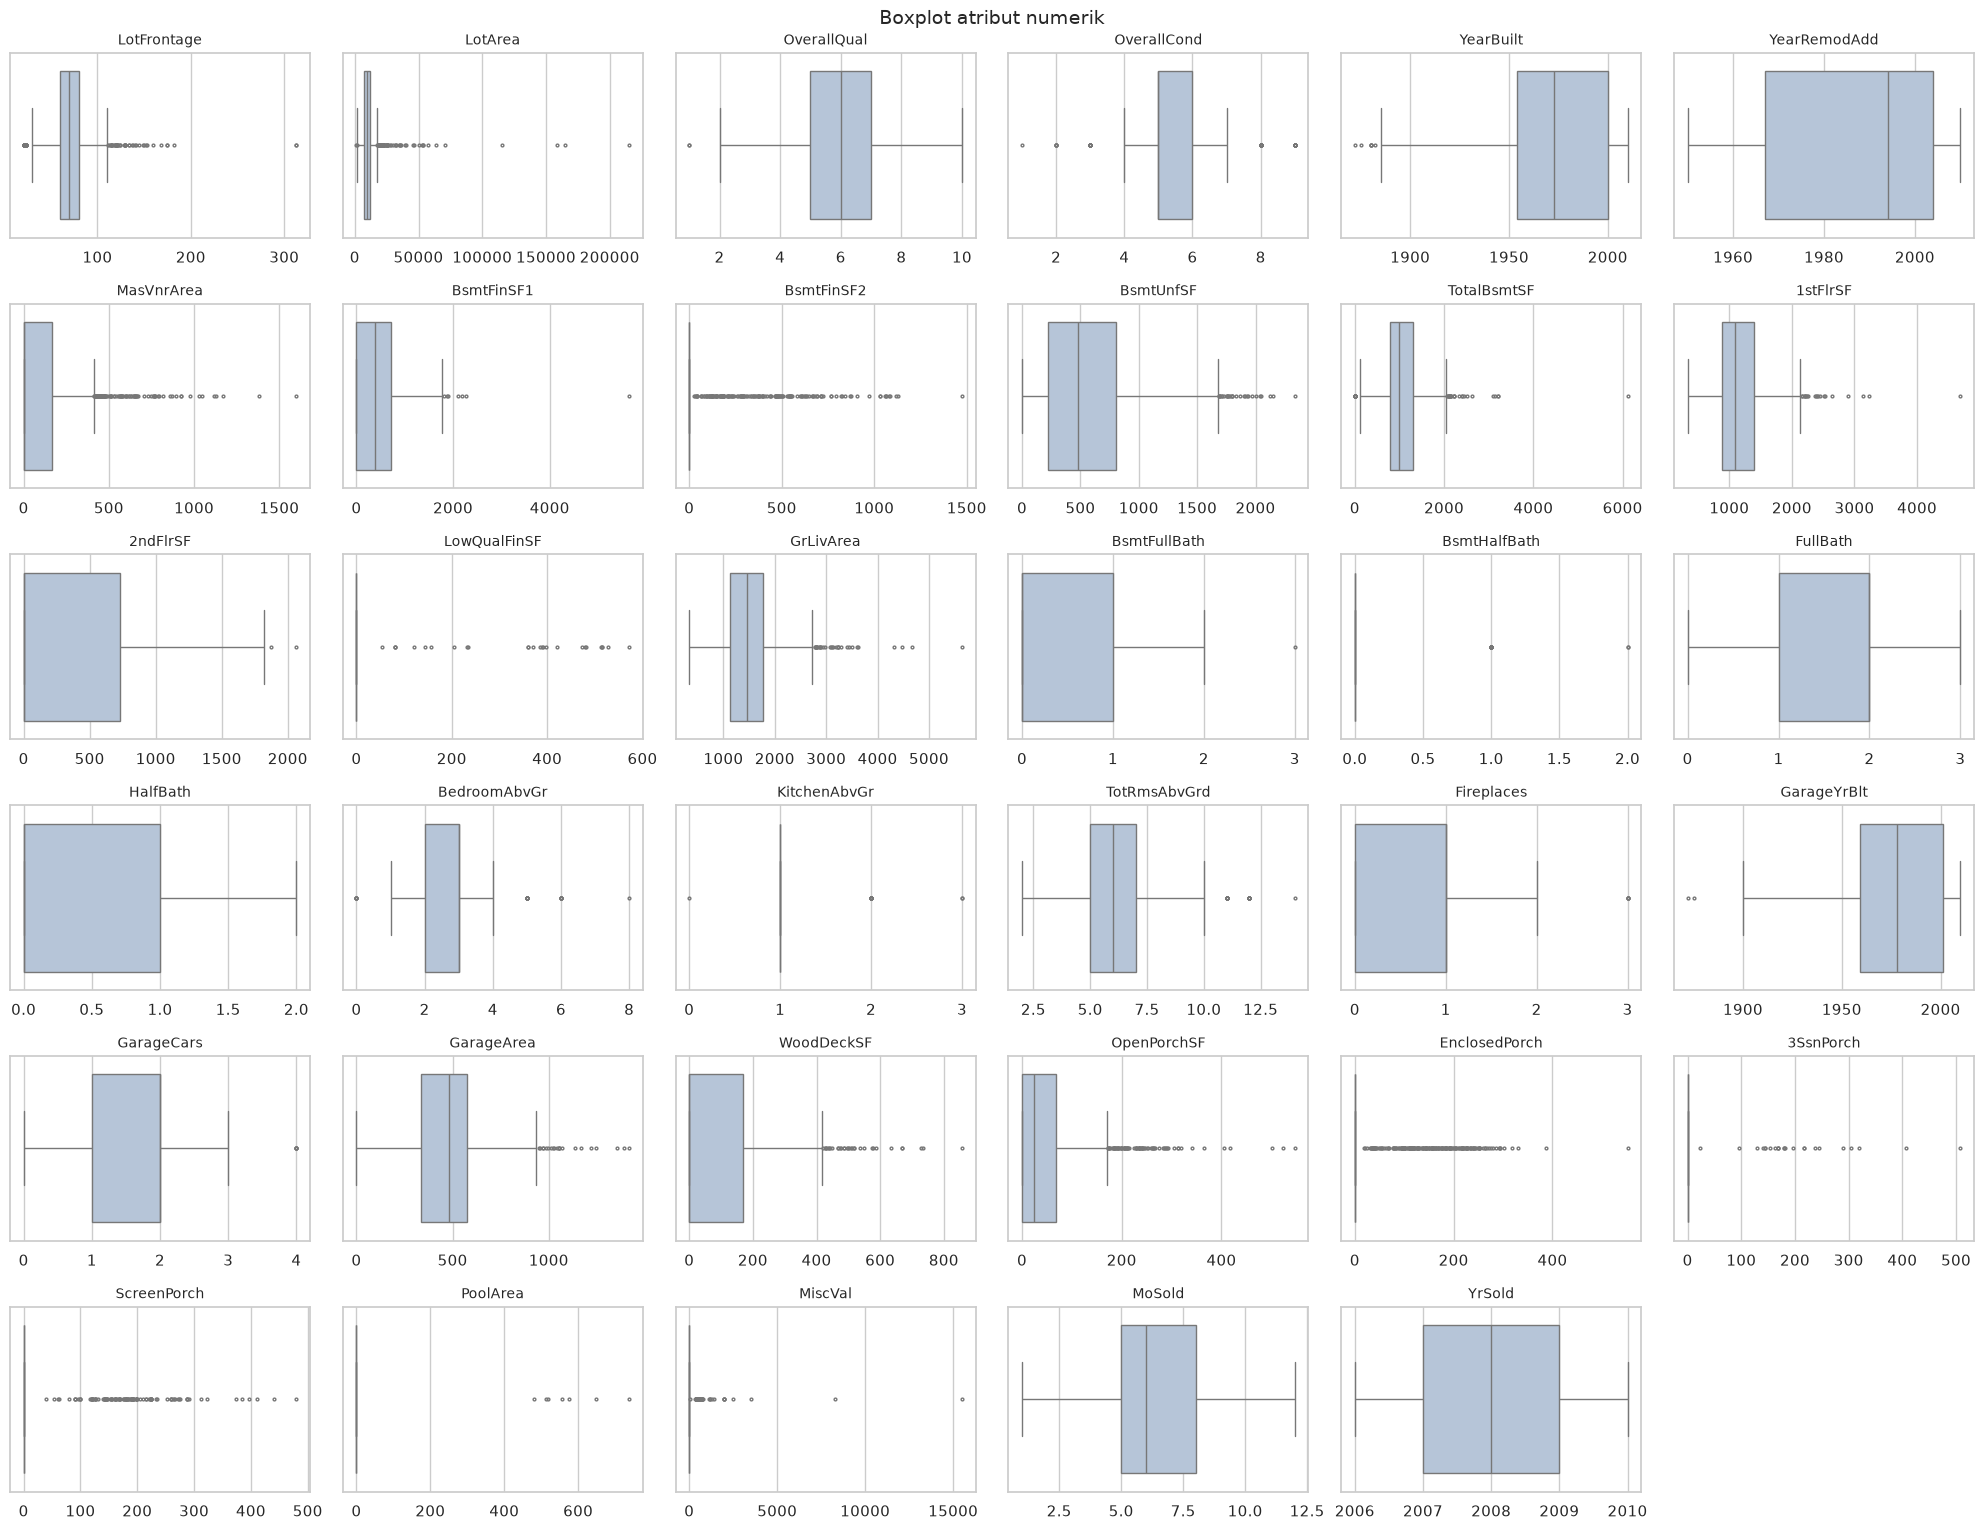

In [10]:
# boxplot semua atribut numerik
ncols = 6
nrows = math.ceil(len(num_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 2.6))

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=df_clean[col], ax=ax, color='lightsteelblue', fliersize=2)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)

plt.suptitle('Boxplot atribut numerik', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# hitung outlier dengan aturan IQR (sama dengan "whisker" di boxplot)
q1 = df_clean[num_cols].quantile(0.25)
q3 = df_clean[num_cols].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

is_outlier = (df_clean[num_cols] < lower) | (df_clean[num_cols] > upper)
display(is_outlier.sum().sort_values(ascending=False).head(15).rename('jumlah outlier'))

n_rows_outlier = is_outlier.any(axis=1).sum()
print(f"Baris yang punya minimal 1 outlier: {n_rows_outlier} dari {len(df_clean)} "
      f"({n_rows_outlier / len(df_clean):.0%})")
print("Kolom dengan IQR = 0:", iqr[iqr == 0].index.tolist())

EnclosedPorch    208
BsmtFinSF2       167
OverallCond      125
ScreenPorch      116
MasVnrArea        98
LotFrontage       93
BsmtHalfBath      82
OpenPorchSF       77
LotArea           69
KitchenAbvGr      68
TotalBsmtSF       61
MiscVal           52
BedroomAbvGr      35
WoodDeckSF        32
GrLivArea         31
Name: jumlah outlier, dtype: int64

Baris yang punya minimal 1 outlier: 870 dari 1460 (60%)
Kolom dengan IQR = 0: ['BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', 'KitchenAbvGr', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']


- **Q**: apakah outlier dihapus semua?
- **S**:
    - 870 dari 1460 baris (60%) punya minimal satu outlier
    - banyak kolom dengan IQR = 0 (`PoolArea`, `MiscVal`, `ScreenPorch`, ...) → mayoritas nilainya 0, jadi *setiap* rumah yang punya fitur tersebut otomatis dianggap outlier
    - kolom diskret (`OverallCond`, `KitchenAbvGr`, `BedroomAbvGr`, ...) juga "punya outlier" padahal nilainya wajar (misal rumah 6 kamar)
- **M**: kalau semua baris outlier dihapus, data hilang >50% → **tidak layak**. Kebanyakan "outlier" di sini adalah nilai asli yang valid, bukan salah input.
- **D**: pakai kombinasi:
    1. **Hapus** hanya outlier yang jelas anomali: rumah dengan `GrLivArea` > 4000 sqft tapi harganya murah (lihat scatter di bawah). Ini juga direkomendasikan oleh pembuat dataset (De Cock, 2011) karena merupakan penjualan parsial yang tidak mencerminkan pasar.
    2. **Sesuaikan (capping/clipping)** ke batas IQR untuk atribut **kontinu** (luas, lebar lahan, dll.) → data tidak hilang tapi nilai ekstrem tidak mendominasi saat standarisasi & PCA.
    3. **Biarkan** atribut tahun, atribut diskret/ordinal, dan atribut ber-IQR 0 — capping di sini justru merusak informasi (misalnya `PoolArea` akan jadi 0 semua).

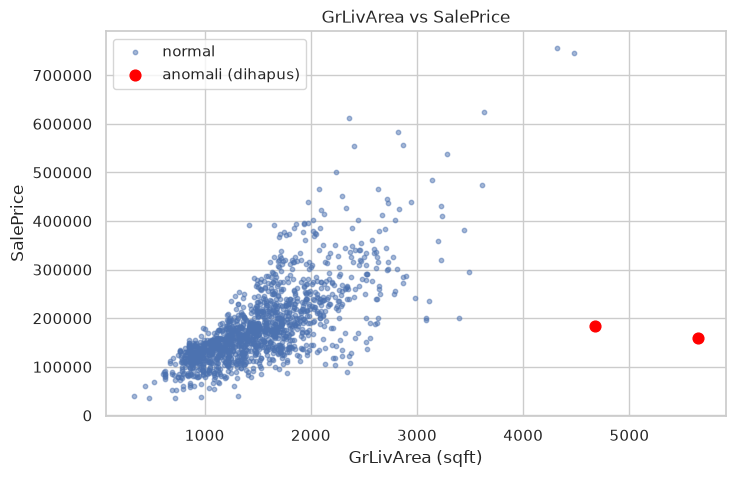

Baris anomali: 2
Shape setelah hapus anomali: (1458, 75)


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
anomali = (df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)
ax.scatter(df_clean['GrLivArea'], df_clean['SalePrice'], s=10, alpha=0.5, label='normal')
ax.scatter(df_clean.loc[anomali, 'GrLivArea'], df_clean.loc[anomali, 'SalePrice'],
           s=60, color='red', label='anomali (dihapus)')
ax.set_xlabel('GrLivArea (sqft)')
ax.set_ylabel('SalePrice')
ax.set_title('GrLivArea vs SalePrice')
ax.legend()
plt.show()

print("Baris anomali:", anomali.sum())
df_clean = df_clean[~anomali].reset_index(drop=True)
print("Shape setelah hapus anomali:", df_clean.shape)

In [13]:
# capping atribut kontinu ke batas IQR
year_cols = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold', 'MoSold']

q1 = df_clean[num_cols].quantile(0.25)
q3 = df_clean[num_cols].quantile(0.75)
iqr = q3 - q1

cap_cols = [c for c in num_cols
            if c not in year_cols
            and df_clean[c].nunique() > 25   # kontinu, bukan diskret/ordinal
            and iqr[c] > 0]                  # bukan kolom yang mayoritas 0
print("Kolom yang di-capping:", cap_cols)

before = df_clean[cap_cols].copy()
for c in cap_cols:
    df_clean[c] = df_clean[c].clip(lower=q1[c] - 1.5 * iqr[c], upper=q3[c] + 1.5 * iqr[c])

Kolom yang di-capping: ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF']


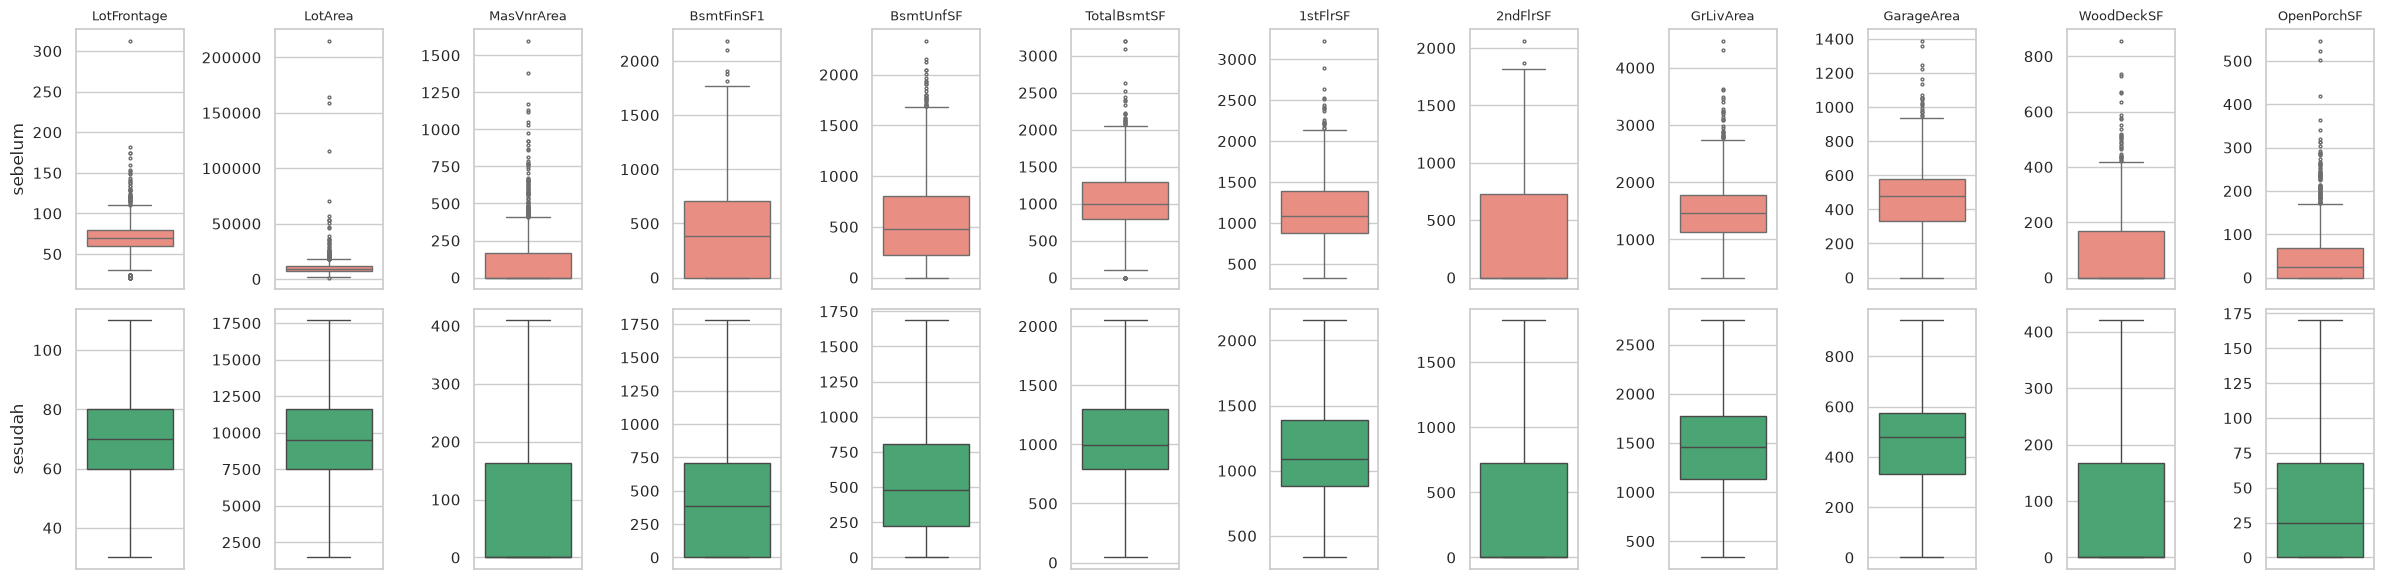

In [14]:
# bandingkan sebelum vs sesudah capping
fig, axes = plt.subplots(2, len(cap_cols), figsize=(2 * len(cap_cols), 6))
for i, c in enumerate(cap_cols):
    sns.boxplot(y=before[c], ax=axes[0, i], color='salmon', fliersize=2)
    sns.boxplot(y=df_clean[c], ax=axes[1, i], color='mediumseagreen', fliersize=2)
    axes[0, i].set_title(c, fontsize=9)
    axes[0, i].set_ylabel('')
    axes[1, i].set_ylabel('')
axes[0, 0].set_ylabel('sebelum')
axes[1, 0].set_ylabel('sesudah')
plt.tight_layout()
plt.show()

## 4. Transformasi Data

Target `SalePrice` dipisah dulu supaya tidak ikut ditransformasi (nanti dipakai sebagai label / untuk analisis korelasi).

**Standarisasi (z-score)** dipilih dibanding normalisasi min-max karena:
- PCA mengukur varians, jadi semua atribut harus berada di skala yang sama (kalau tidak, `LotArea` yang nilainya puluhan ribu akan mendominasi)
- z-score tidak terlalu terpengaruh sisa nilai ekstrem dibanding min-max (min-max sangat tergantung nilai min & max)

In [15]:
y = df_clean['SalePrice']
X = df_clean.drop(columns='SalePrice')

cat_cols = [c for c in X.columns if c not in num_cols]
print(f"{len(num_cols)} numerik, {len(cat_cols)} kategoris")

35 numerik, 39 kategoris


In [16]:
scaler = StandardScaler()
X_num = pd.DataFrame(scaler.fit_transform(X[num_cols]), columns=num_cols, index=X.index)

# cek: mean ≈ 0, std ≈ 1
display(X_num.describe().T[['mean', 'std', 'min', 'max']].round(3).head(10))

,mean,std,min,max
LotFrontage,0.0,1.0,-2.195,2.258
LotArea,-0.0,1.0,-2.281,2.245
OverallQual,-0.0,1.0,-3.702,2.839
OverallCond,0.0,1.0,-4.112,3.076
YearBuilt,0.0,1.0,-3.287,1.285
YearRemodAdd,0.0,1.0,-1.688,1.220
MasVnrArea,0.0,1.0,-0.667,2.404
BsmtFinSF1,-0.0,1.0,-1.018,3.111
BsmtFinSF2,-0.0,1.0,-0.289,8.846
BsmtUnfSF,-0.0,1.0,-1.305,2.598


In [17]:
# one-hot encoding atribut kategoris
X_cat = pd.get_dummies(X[cat_cols], dtype=int)
print("Kolom kategoris:", len(cat_cols), "→ kolom one-hot:", X_cat.shape[1])
display(X_cat.head())

Kolom kategoris: 39 → kolom one-hot: 259


,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0


In [18]:
X_final = pd.concat([X_num, X_cat], axis=1)
print("Shape setelah transformasi:", X_final.shape)

Shape setelah transformasi: (1458, 294)


- **Q**: apa efek one-hot encoding?
- **S**: 39 atribut kategoris menjadi 259 kolom one-hot; total fitur jadi 294 (35 numerik + 259 dummy)
- **M**: setiap kategori jadi satu kolom 0/1 → data jadi sangat lebar dan sparse, banyak kolom yang redundan
- **D**: reduksi dimensi

## 5. Reduksi Dimensi

### 5.1 Analisis Korelasi

Korelasi dihitung pada atribut numerik (korelasi Pearson antar kolom dummy 0/1 kurang bermakna). Pasangan dengan |r| > 0.8 dianggap sangat berkorelasi (redundan). Dari tiap pasangan, yang dibuang adalah atribut yang korelasinya dengan `SalePrice` **lebih lemah**.

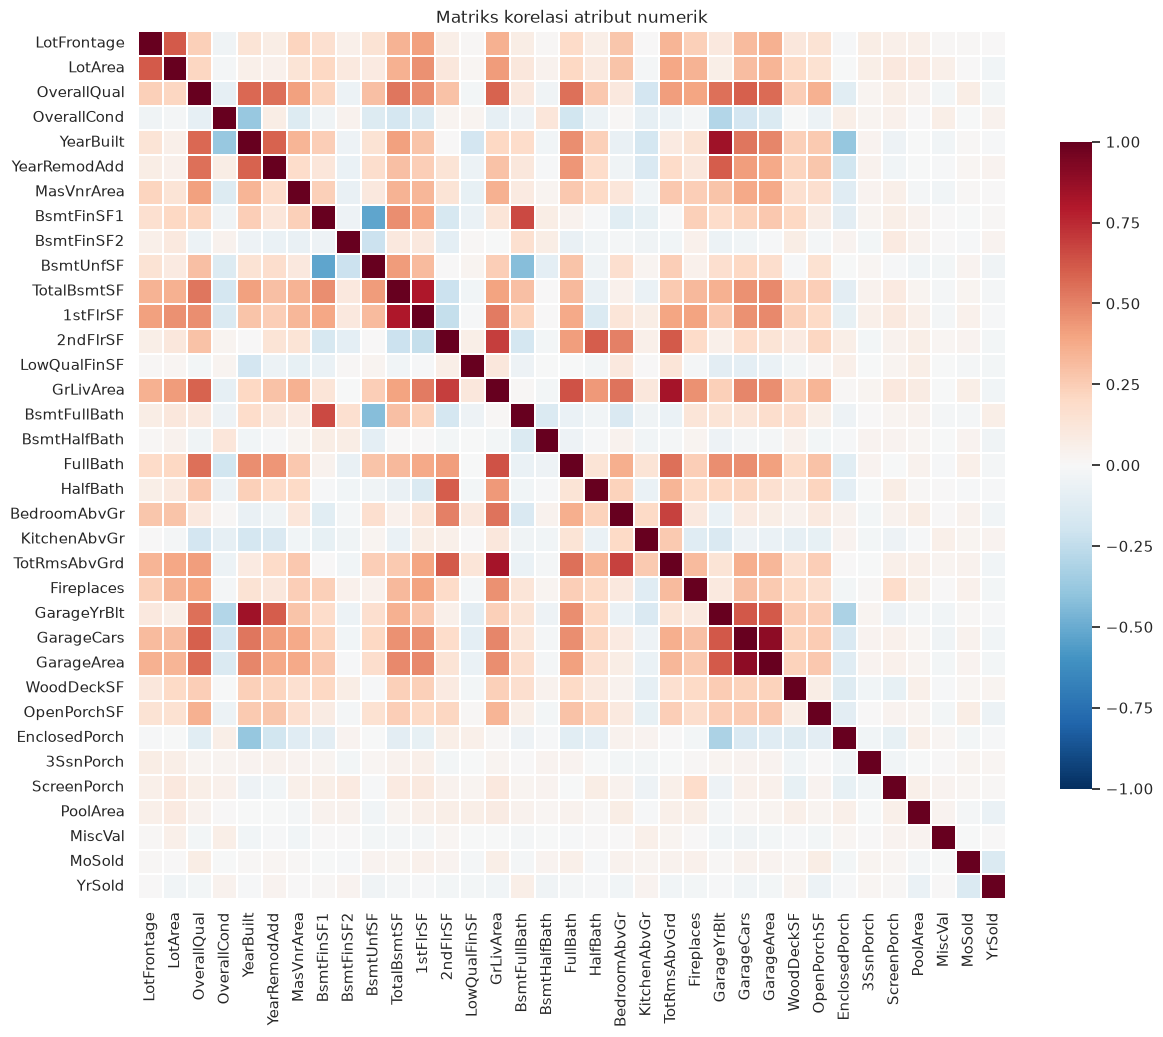

In [19]:
corr = X_num.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.3, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Matriks korelasi atribut numerik')
plt.show()

In [20]:
# ambil pasangan unik (segitiga atas) dengan |r| > 0.8
threshold = 0.8
upper_tri = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = upper_tri.stack()
pairs = pairs[pairs.abs() > threshold].sort_values(key=abs, ascending=False)

target_corr = X_num.corrwith(y).abs()

rows, to_drop = [], []
for (a, b), r in pairs.items():
    if a in to_drop or b in to_drop:
        continue
    drop = a if target_corr[a] < target_corr[b] else b
    to_drop.append(drop)
    rows.append({'atribut_1': a, 'atribut_2': b, 'r': r,
                 '|r| atr_1 vs SalePrice': target_corr[a],
                 '|r| atr_2 vs SalePrice': target_corr[b],
                 'dibuang': drop})

display(pd.DataFrame(rows).round(3))
print("Atribut yang dibuang:", to_drop)

,atribut_1,atribut_2,r,|r| atr_1 vs SalePrice,|r| atr_2 vs SalePrice,dibuang
0,GarageCars,GarageArea,0.894,0.641,0.633,GarageArea
1,YearBuilt,GarageYrBlt,0.845,0.524,0.509,GarageYrBlt
2,GrLivArea,TotRmsAbvGrd,0.834,0.712,0.538,TotRmsAbvGrd
3,TotalBsmtSF,1stFlrSF,0.805,0.640,0.624,1stFlrSF


Atribut yang dibuang: ['GarageArea', 'GarageYrBlt', 'TotRmsAbvGrd', '1stFlrSF']


In [21]:
X_reduced = X_final.drop(columns=to_drop)
print("Shape sebelum:", X_final.shape, "→ sesudah buang korelasi tinggi:", X_reduced.shape)

Shape sebelum: (1458, 294) → sesudah buang korelasi tinggi: (1458, 290)


Pasangan yang muncul masuk akal secara domain:
- `GarageCars` ↔ `GarageArea`: garasi lebih luas = muat lebih banyak mobil
- `YearBuilt` ↔ `GarageYrBlt`: garasi umumnya dibangun bersamaan dengan rumah (apalagi NaN-nya tadi diisi `YearBuilt`)
- `GrLivArea` ↔ `TotRmsAbvGrd`: luas lantai makin besar, jumlah ruangan makin banyak
- `TotalBsmtSF` ↔ `1stFlrSF`: basement biasanya berada tepat di bawah lantai 1 dengan luas mirip

### 5.2 PCA (Principal Component Analysis)

PCA dijalankan pada seluruh fitur hasil transformasi (numerik terstandarisasi + dummy one-hot). Jumlah komponen dipilih sehingga **≥ 95% varians** tetap terjaga.

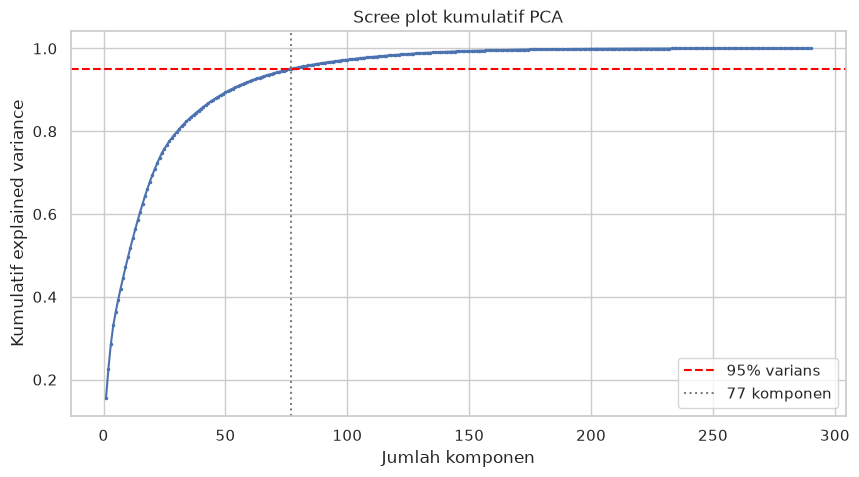

Butuh 77 komponen untuk menjelaskan 95% varians (dari 290 fitur)


In [22]:
pca_full = PCA().fit(X_reduced)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.argmax(cum_var >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker='.', markersize=3)
ax.axhline(0.95, color='red', linestyle='--', label='95% varians')
ax.axvline(n_95, color='gray', linestyle=':', label=f'{n_95} komponen')
ax.set_xlabel('Jumlah komponen')
ax.set_ylabel('Kumulatif explained variance')
ax.set_title('Scree plot kumulatif PCA')
ax.legend()
plt.show()

print(f"Butuh {n_95} komponen untuk menjelaskan 95% varians (dari {X_reduced.shape[1]} fitur)")

In [23]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_reduced)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i + 1}' for i in range(X_pca.shape[1])])
display(df_pca.head())
print("Shape hasil PCA:", df_pca.shape)
print("Varians yang dijelaskan PC1-PC5:", pca.explained_variance_ratio_[:5].round(3))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC68,PC69,PC70,PC71,PC72,PC73,PC74,PC75,PC76,PC77
0,2.190009,0.184681,-1.469169,-2.535047,1.074480,-0.108910,-0.830409,0.932743,0.147017,-0.712965,...,0.004557,0.141803,0.017626,0.064899,-0.195912,0.173279,-0.000314,-0.209692,-0.066499,0.171401
1,-0.064637,-1.435134,1.543899,0.086311,-1.669483,-1.172049,-1.022905,-2.010830,-1.809730,1.353359,...,0.261162,-0.132273,0.001996,0.053913,-0.077134,0.354837,-0.184010,0.556215,0.388007,-0.152420
2,2.921277,0.518567,-0.636617,-1.785326,0.362531,-0.217163,0.136434,-0.129661,0.076217,-0.745828,...,0.068529,0.399381,-0.017214,0.292138,-0.075339,0.060356,0.078092,-0.438201,-0.109690,0.037545
3,-1.136678,1.587495,1.282056,-0.034760,-0.491736,2.816698,0.609579,0.815359,0.141477,-1.914558,...,0.384131,1.008319,-0.661565,-0.026420,-0.239942,0.192310,-0.207498,0.089258,0.468098,0.155778
4,5.025364,0.989640,0.791375,-1.337150,0.680395,-0.325518,0.211725,-0.734254,-0.582651,-0.768025,...,-0.190427,-0.125578,0.037689,-0.156787,0.193867,0.111560,0.045415,0.170403,0.103119,-0.424319


Shape hasil PCA: (1458, 77)
Varians yang dijelaskan PC1-PC5: [0.154 0.072 0.06  0.045 0.033]


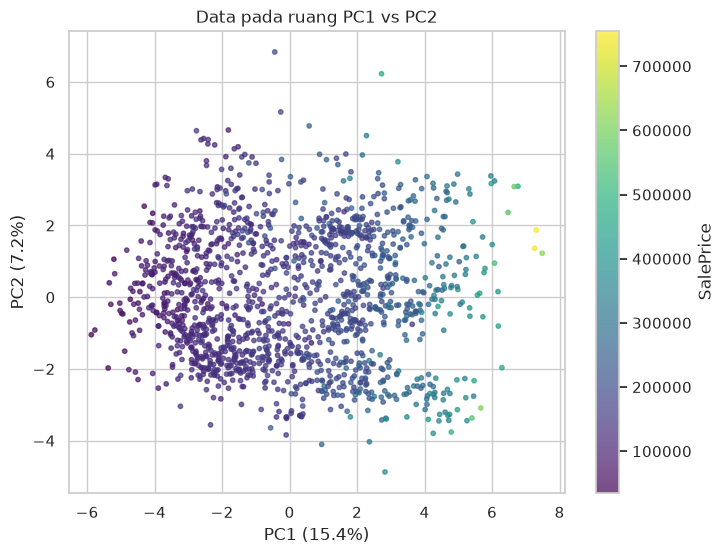

In [24]:
# visualisasi 2 komponen pertama, warna = harga rumah
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df_pca['PC1'], df_pca['PC2'], c=y, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(sc, label='SalePrice')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Data pada ruang PC1 vs PC2')
plt.show()

In [25]:
# atribut apa yang paling berkontribusi ke PC1?
loadings = pd.Series(pca.components_[0], index=X_reduced.columns)
display(loadings.abs().sort_values(ascending=False).head(10).rename('|loading PC1|'))

OverallQual     0.312747
GarageCars      0.277188
YearBuilt       0.276320
GrLivArea       0.271225
FullBath        0.262068
YearRemodAdd    0.240104
TotalBsmtSF     0.233471
MasVnrArea      0.186748
Fireplaces      0.179297
OpenPorchSF     0.171473
Name: |loading PC1|, dtype: float64

- **Q**: seberapa besar dimensi berkurang, dan apakah hasilnya masih bermakna?
- **S**: 290 fitur → 77 komponen utama dengan tetap menjaga 95% varians; PC1 sendiri menjelaskan ~15%; di scatter PC1 vs PC2, warna (harga) bergradasi mengikuti PC1
- **M**:
    - PC1 didominasi atribut kualitas & ukuran rumah (lihat loading) → PC1 kurang lebih merepresentasikan "seberapa besar/bagus rumahnya", yang memang berkaitan erat dengan harga
    - catatan: kolom dummy (0/1) variansnya kecil dibanding kolom numerik terstandarisasi (var = 1), sehingga komponen awal PCA lebih banyak ditentukan atribut numerik
- **D**: `df_pca` + `y` siap dipakai untuk pemodelan regresi

## Ringkasan

| Tahap | Perubahan |
|---|---|
| Import | 1460 baris × 81 kolom |
| Pembersihan | hapus 5 kolom >50% missing + `Id`; sisa missing diisi sesuai arti kolom |
| Outlier | hapus 2 baris anomali (`GrLivArea` besar, harga murah); capping IQR pada atribut kontinu |
| Transformasi | standarisasi z-score atribut numerik, one-hot encoding atribut kategoris |
| Transformasi (hasil) | 1458 × 294 |
| Reduksi | buang 4 atribut berkorelasi > 0.8 (294 → 290), lalu PCA 95% varians → **1458 × 77** |